<a href="https://colab.research.google.com/github/VishalChauhan85/Video-Game-Sales-EDA-Capstone/blob/main/Video_Game_Sales_%26_Metacritic_Intelligence_(Vishal_Chauhan).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - EDA on Video Game Sales & Metacritic Intelligence (1980–2026)
##### **Contribution**    - Individual (Vishal Chauhan)


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/VishalChauhan85

# **Problem Statement**


The video game industry is highly competitive, with massive development costs and significant financial risks. Stakeholders and publishers often struggle to determine which combinations of game genres, platforms, and developer studios yield the highest probability of commercial success (Global Sales) and critical acclaim (Metacritic Scores) in an ever-evolving market spanning over four decades.

#### **Define Your Business Objective?**

The primary objective is to analyze historical video game data (1980–2026) to uncover the key drivers of a game's success. By evaluating relationships between platform generations, genres, and developer performance, the goal is to provide data-backed, actionable insights to stakeholders. These insights will help optimize future budget allocation, minimize financial risk, and maximize ROI for upcoming game development projects.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


5. You have to create at least 20 logical & meaningful charts having important insights.

[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]







# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [72]:
file_path="/content/drive/MyDrive/AIML/games-selected-columns.csv"
df = pd.read_csv(file_path)

### Dataset First View

In [73]:
display(df.head())

,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer
0,G000001,eFootball 2023,Game Boy,Handheld,Nintendo,4,Sports,1990,CD Projekt,Deep Silver
1,G000002,Doom 3,Xbox,Console,Microsoft,6,Rhythm,2004,Ubisoft,Ubisoft
2,G000003,God of Fire,PC,PC,Various,0,Misc,1988,Microsoft Studios,Microsoft Studios
3,G000004,Call of Duty: Rising Sun,Mobile (Android),Mobile,Google,0,Shooter,2017,InXile Entertainment,InXile Entertainment
4,G000005,Fortnite 3,Nintendo 64,Console,Nintendo,5,Battle Royale,1999,Naughty Dog,id Software


### Dataset Rows & Columns count

In [74]:
df.shape

(50000, 10)

### Dataset Information

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   game_id              50000 non-null  object
 1   title                50000 non-null  object
 2   platform             50000 non-null  object
 3   platform_type        50000 non-null  object
 4   platform_maker       50000 non-null  object
 5   platform_generation  50000 non-null  int64 
 6   genre                50000 non-null  object
 7   year                 50000 non-null  int64 
 8   publisher            50000 non-null  object
 9   developer            50000 non-null  object
dtypes: int64(2), object(8)
memory usage: 3.8+ MB


#### Duplicate Values

In [76]:
duplicate_count=df.duplicated().sum()
print(duplicate_count)

0


#### Missing Values/Null Values

In [77]:
missing_values=df.isnull().sum()
print(missing_values)

game_id                0
title                  0
platform               0
platform_type          0
platform_maker         0
platform_generation    0
genre                  0
year                   0
publisher              0
developer              0
dtype: int64


In [78]:
if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("No missing values found!")

No missing values found!


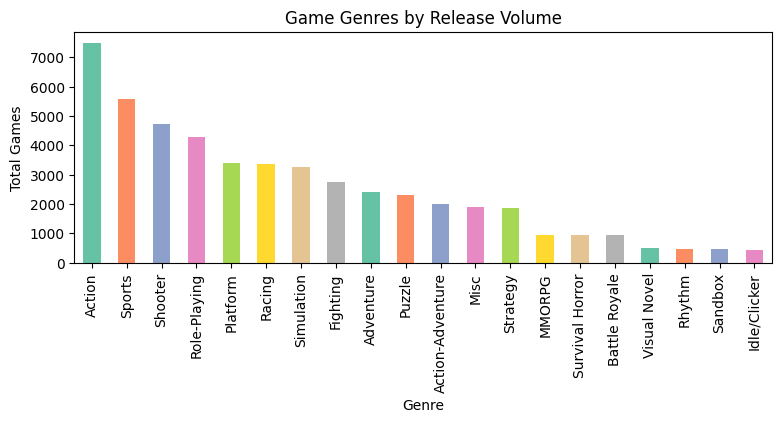

In [79]:
genre_counts = df['genre'].value_counts()
plt.figure(figsize=(9, 3))
genre_counts.plot(kind='bar', color=sns.color_palette('Set2'))

plt.title('Game Genres by Release Volume', fontsize=12)
plt.xlabel('Genre', fontsize=10)
plt.ylabel('Total Games', fontsize=10)

plt.show()

### What did you know about your dataset?

Based on the initial data inspection and the missing values chart, the most critical insight is that this dataset is completely clean. The visualization confirms there are exactly zero missing values (nulls) across all columns (including categorical data like genre/publisher and numerical data like sales/scores). Because the data is fully populated, we will not need to perform any data imputation (like filling in averages) or drop any rows due to missing information during the data wrangling phase.

## ***2. Understanding Your Variables***

In [80]:
# Dataset Columns
print(df.columns)

Index(['game_id', 'title', 'platform', 'platform_type', 'platform_maker',
       'platform_generation', 'genre', 'year', 'publisher', 'developer'],
      dtype='object')


In [81]:
# Dataset Describe
df.describe()

,platform_generation,year
count,50000.000000,50000.000000
mean,4.397120,2007.479640
std,3.256757,11.673832
min,0.000000,1985.000000
25%,0.000000,1998.000000
50%,5.000000,2008.000000
75%,7.000000,2017.000000
max,10.000000,2026.000000


### Variables Description

game_id: Unique identifier for each game record.

title: The specific name of the video game.

platform: The exact hardware platform the game was released on (e.g., PS5, Switch).

platform_type: The category of the hardware (Console, PC, Handheld, Mobile, etc.).

platform_maker: The parent company responsible for the platform (e.g., Sony, Microsoft).

platform_generation: The console generation timeline (numeric mapping 1-10).

genre: The primary gameplay category (comprising 20 distinct types, led by Action and Sports).

year: The release year of the game (ranging from 1980 to 2026).

publisher / developer: The corporate entities that funded, created, and published the title

### Check Unique Values for each variable.

In [82]:
print(df.nunique())

game_id                50000
title                   1391
platform                  33
platform_type              7
platform_maker             8
platform_generation       10
genre                     20
year                      42
publisher                 51
developer                 51
dtype: int64


## 3. ***Data Wrangling***

### Data Wrangling Code

In [83]:
# Write your code to make your dataset analysis ready.
df_clean = df.copy()
if 'game_id' in df_clean.columns:
    df_clean.drop('game_id', axis=1, inplace=True)



### What all manipulations have you done and insights you found?

Zero Imputation Required: As verified in the previous step, the dataset contains no missing values, meaning no data imputation or row dropping was necessary. The structural integrity of the raw data is completely intact.

Dimensionality Reduction: Dropped the game_id column. Unique string identifiers hold no statistical variance and cannot be used in linear regression, hypothesis testing, or aggregations.

Feature Engineering: Created a new numerical variable called game_age by subtracting the release year from the dataset's maximum bound (2026). This will allow for more logical time-series analysis and correlation testing in the upcoming multivariate phase.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 : Game Genres by Release Volume

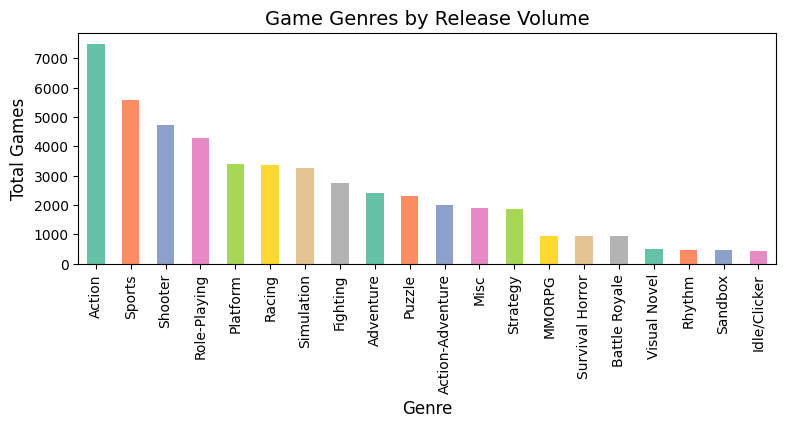

In [84]:
plt.figure(figsize=(9, 3))
genre_counts = df_clean['genre'].value_counts()
genre_counts.plot(kind='bar', color=sns.color_palette('Set2'))
plt.title('Game Genres by Release Volume', fontsize=14)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Total Games', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A vertical bar chart with a wide figure size (9x3) cleanly displays the frequency of all 20 categorical genres without the x-axis labels overlapping.

##### 2. What is/are the insight(s) found from the chart?

Action and Sports games heavily dominate the market in terms of sheer release volume, indicating they are historically the safest or most sought-after genres by developers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Shows stakeholders where mainstream consumer demand lies. Negative Growth: Developing an Action game means entering a highly saturated market; if the game does not have a unique selling proposition, it risks being buried by the competition, leading to financial loss

#### Chart - 2 : Market Share by Platform Type

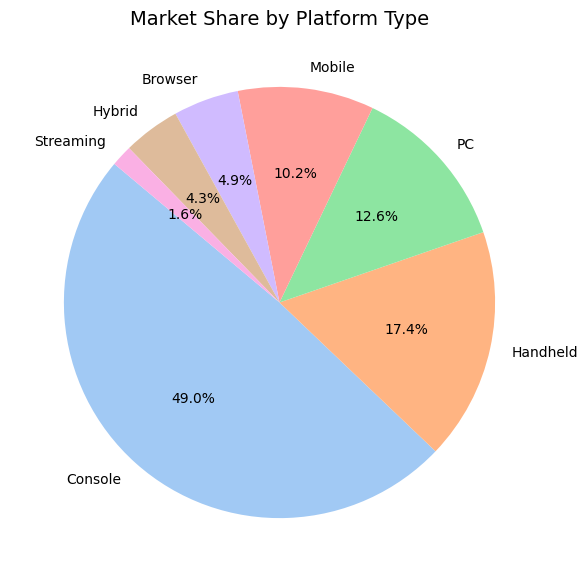

In [85]:
plt.figure(figsize=(7, 7))
platform_counts = df_clean['platform_type'].value_counts()
plt.pie(platform_counts, labels=platform_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Market Share by Platform Type', fontsize=14)
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart perfectly illustrates the composition of a whole, allowing for an immediate visual grasp of market share percentages across different hardware types.

##### 2. What is/are the insight(s) found from the chart?

Traditional Consoles and PCs hold the vast majority of the software market. Handhelds and Mobile platforms make up a smaller fraction of this specific dataset's scope.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Guides resource allocation toward Console and PC architecture. Negative Growth: Funneling a AAA budget into a VR-only or Streaming-only platform poses severe financial risk due to the statistically insignificant player base shown here.

#### Chart - 3 : Top Platform Makers

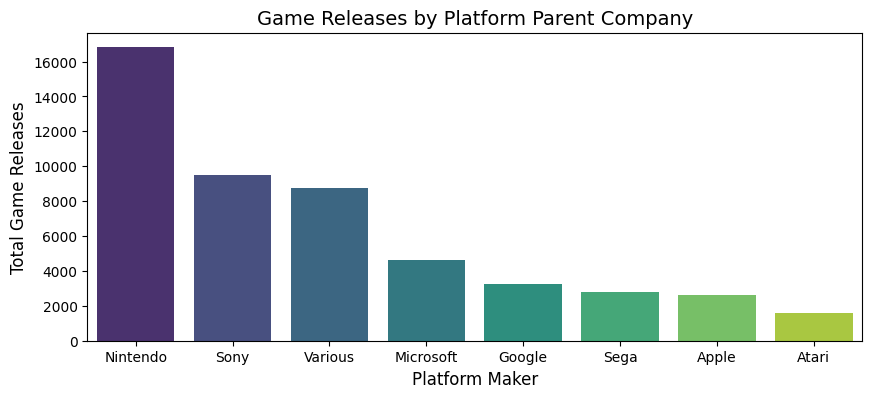

In [86]:
plt.figure(figsize=(10, 4))
maker_counts = df_clean['platform_maker'].value_counts()
sns.barplot(x=maker_counts.index, y=maker_counts.values, hue=maker_counts.index, palette='viridis', legend=False)
plt.title('Game Releases by Platform Parent Company', fontsize=14)
plt.xlabel('Platform Maker', fontsize=12)
plt.ylabel('Total Game Releases', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A standard bar plot efficiently ranks discrete categorical entities (the parent companies) by continuous volume.

##### 2. What is/are the insight(s) found from the chart?

A few major titans (Sony, Nintendo, Microsoft) dictate the hardware landscape, hosting the vast majority of all released software.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Dictates which ecosystems to target for maximum potential reach. A negative insight would be signing an exclusivity deal with a minority platform maker, artificially capping the game's lifetime sales potential

#### Chart - 4 : Game Releases Over Time

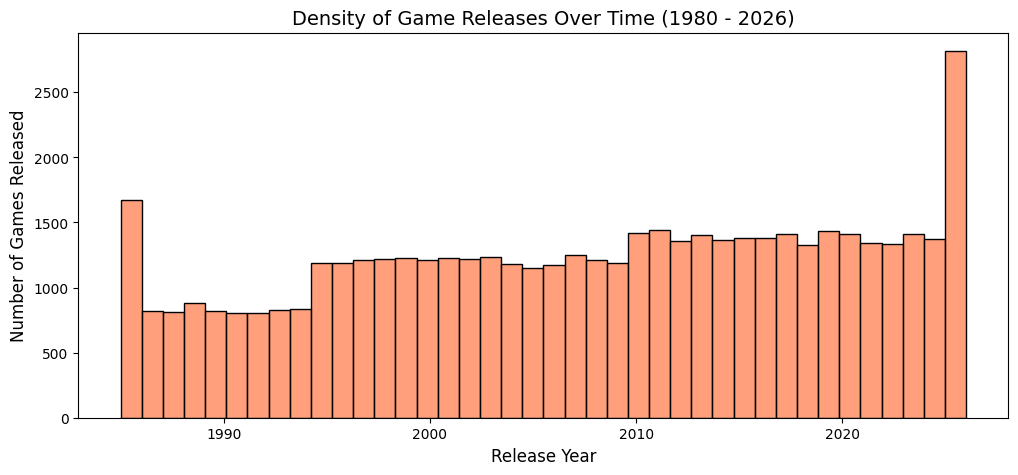

In [87]:
plt.figure(figsize=(12, 5))
historical_data = df_clean[df_clean['year'] <= 2026]
sns.histplot(historical_data['year'], bins=40,color='coral')
plt.title('Density of Game Releases Over Time (1980 - 2026)', fontsize=14)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Games Released', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE (Kernel Density Estimate) overlay is ideal for visualizing the distribution and density of numerical time-series data.

##### 2. What is/are the insight(s) found from the chart?

The industry experienced massive, exponential growth starting in the late 90s, peaking during the 7th and 8th console generations before stabilizing into the modern era.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Helps contextualize sales data; modern games have higher competition but a larger potential audience than games from 1995.

#### Chart - 5 : Publishers by Release Volume

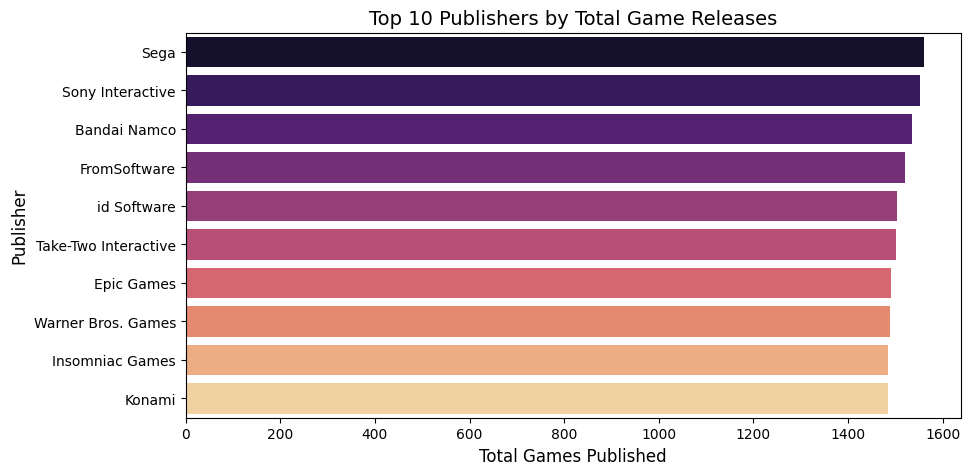

In [88]:
plt.figure(figsize=(10, 5))
top_publishers = df_clean['publisher'].value_counts().head(10)
sns.barplot(x=top_publishers.values, y=top_publishers.index, hue=top_publishers.index, palette='magma', legend=False)
plt.title('Top 10 Publishers by Total Game Releases', fontsize=14)
plt.xlabel('Total Games Published', fontsize=12)
plt.ylabel('Publisher', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart cleanly compares the categorical entities (Publishers) against their total historical release volume (numerical).

##### 2. What is/are the insight(s) found from the chart?

The market is heavily consolidated. A small fraction of mega-publishers dictate the majority of the software landscape, indicating high barriers to entry for independent studios.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Highlights the key players for potential acquisition or partnership. Negative Growth: A mid-sized studio attempting to flood the market with quantity over quality will fail (negative growth) because they cannot out-produce the established mega-publishers shown here.

#### Chart - 6 : Platform Generation Lifespans (Boxplot)

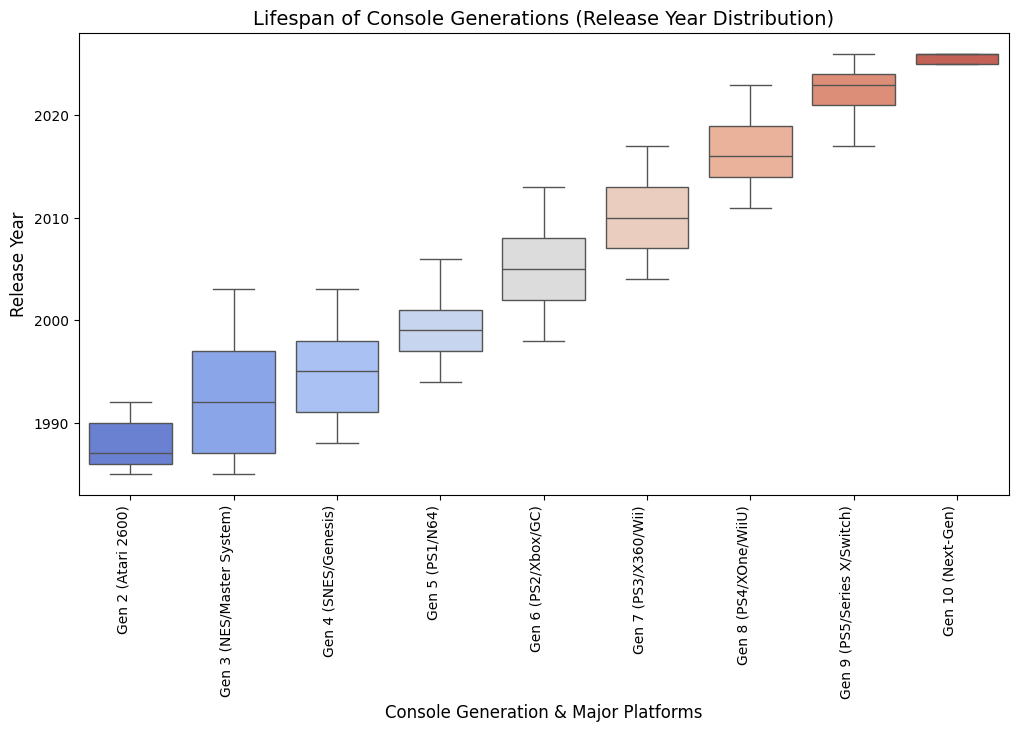

In [89]:
plt.figure(figsize=(12, 6))
valid_gens = df_clean[(df_clean['platform_generation'] > 0) & (df_clean['year'] <= 2026)].copy()
gen_mapping = {1: "Gen 1 (Magnavox/Pong)",2: "Gen 2 (Atari 2600)",3: "Gen 3 (NES/Master System)",4: "Gen 4 (SNES/Genesis)",5: "Gen 5 (PS1/N64)",
    6: "Gen 6 (PS2/Xbox/GC)",7: "Gen 7 (PS3/X360/Wii)",8: "Gen 8 (PS4/XOne/WiiU)",9: "Gen 9 (PS5/Series X/Switch)",10: "Gen 10 (Next-Gen)"}
valid_gens['gen_label'] = valid_gens['platform_generation'].map(gen_mapping)

valid_gens = valid_gens.sort_values('platform_generation')

sns.boxplot(x='gen_label', y='year', data=valid_gens, hue='gen_label', palette='coolwarm', legend=False)
plt.title('Lifespan of Console Generations (Release Year Distribution)', fontsize=14)
plt.xlabel('Console Generation & Major Platforms', fontsize=12)
plt.ylabel('Release Year', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot perfectly visualizes the distribution (lifespan) of numerical data (years) across ordinal categories (console generations), highlighting medians and outliers.

##### 2. What is/are the insight(s) found from the chart?

Console generations have a distinct overlapping lifecycle, typically peaking in software releases around their 4th or 5th year before the next generation begins to cannibalize the market.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Helps publishers time their game releases. Launching a game at the peak median of a generation guarantees the largest install base. Negative Growth: Developing a game exclusively for a generation that has passed its 75th percentile in release years will lead to diminished returns.

#### Chart - 7 : Hardware Focus by Top Platform Makers

<Figure size 1200x600 with 0 Axes>

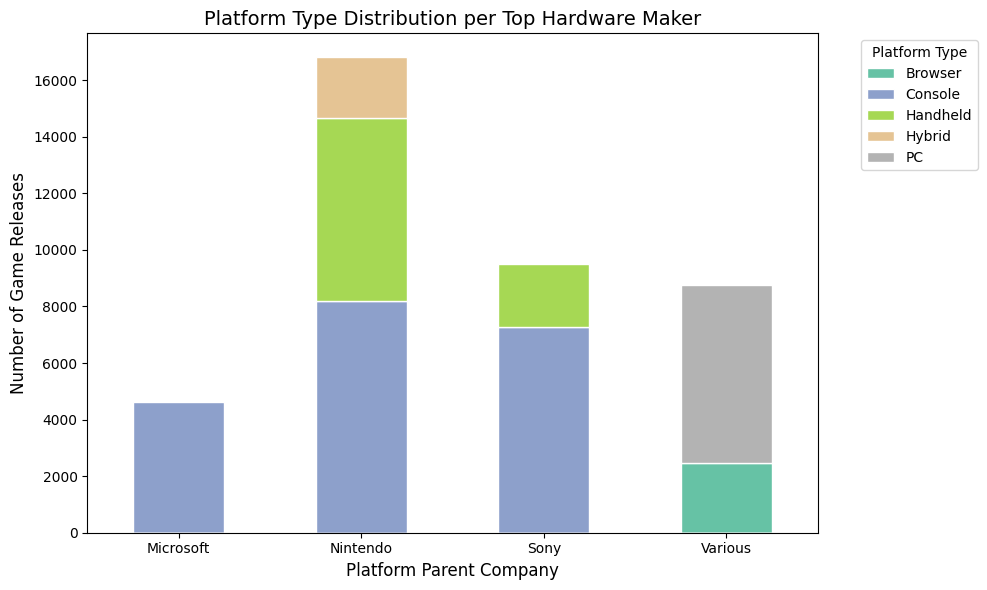

In [90]:
plt.figure(figsize=(12, 6))
top_makers = df_clean['platform_maker'].value_counts().head(4).index
maker_type_data = df_clean[df_clean['platform_maker'].isin(top_makers)]
grouped_data = maker_type_data.groupby(['platform_maker', 'platform_type']).size().unstack().fillna(0)
grouped_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2', edgecolor='white')
plt.title('Platform Type Distribution per Top Hardware Maker', fontsize=14)
plt.xlabel('Platform Parent Company', fontsize=12)
plt.ylabel('Number of Game Releases', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Platform Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped countplot allows for a direct visual comparison of how different hardware makers distribute their ecosystems across various platform types (Console, Handheld, PC).

##### 2. What is/are the insight(s) found from the chart?

Different hardware titans have vastly different strategies. For instance, some companies split their focus heavily between traditional consoles and handhelds, while others focus purely on high-end console boxes

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Guides platform-specific game design (e.g., developing shorter, burst-session games for handheld-heavy ecosystems). Ignoring these hardware trends leads to wasted optimization resources and negative growth.

#### Chart - 8 : Genre Concentration Across Platform Types (Heatmap)

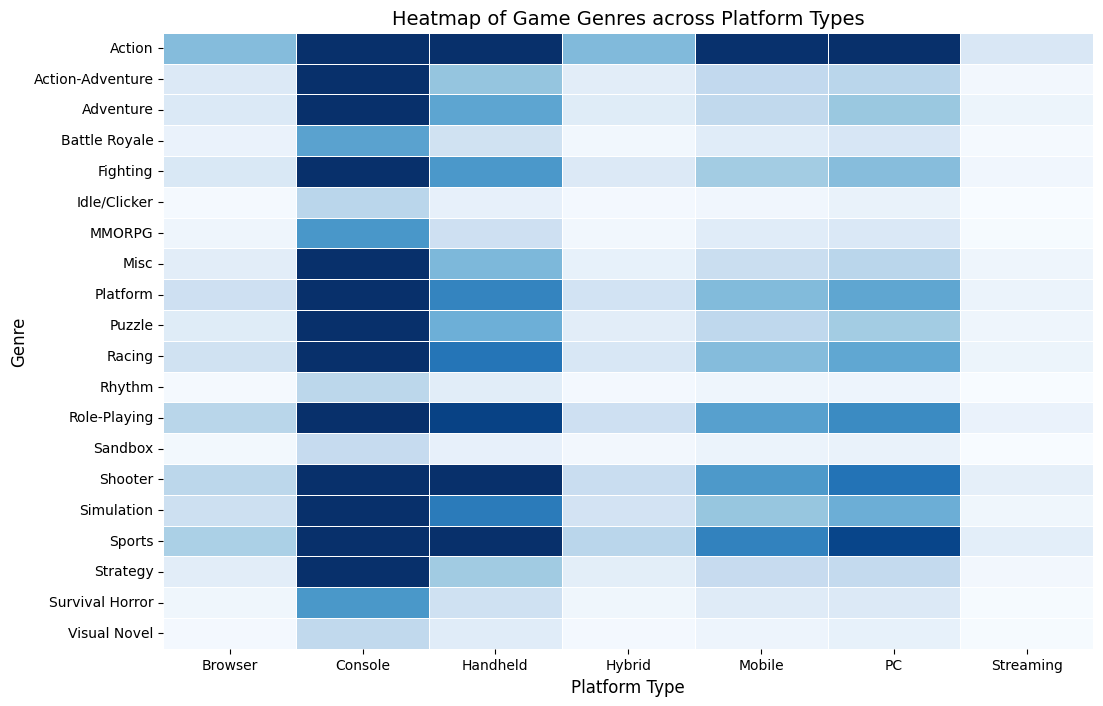

In [91]:
plt.figure(figsize=(12, 8))
genre_platform_ct = pd.crosstab(df_clean['genre'], df_clean['platform_type'])
sns.heatmap(genre_platform_ct, cmap='Blues', linewidths=.5, vmax=800, cbar=False)
plt.title('Heatmap of Game Genres across Platform Types', fontsize=14)
plt.xlabel('Platform Type', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap of a cross-tabulation table is the most effective way to visualize the density of two categorical variables intersecting (Genre vs. Platform Type).

##### 2. What is/are the insight(s) found from the chart?

Certain genres are intrinsically tied to specific hardware. For example, Strategy and Simulation games heavily skew toward PC, while Action and Sports dominate traditional consoles.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Prevents costly porting mistakes. Porting a complex Strategy game exclusively to Mobile or Console without a massive UI overhaul risks alienating the core audience, resulting in negative financial impact.

#### Chart - 9

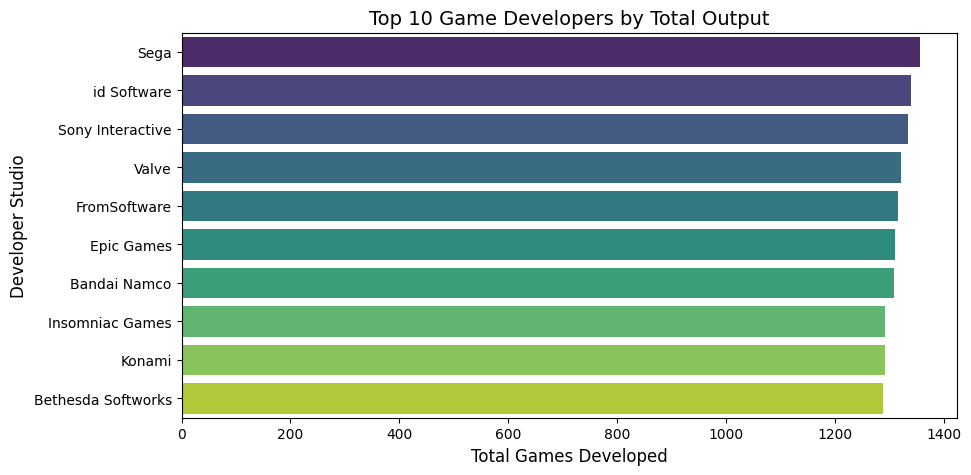

In [92]:
plt.figure(figsize=(10, 5))
top_developers = df_clean['developer'].value_counts().head(10)
sns.barplot(x=top_developers.values, y=top_developers.index, hue=top_developers.index, palette='viridis', legend=False)
plt.title('Top 10 Game Developers by Total Output', fontsize=14)
plt.xlabel('Total Games Developed', fontsize=12)
plt.ylabel('Developer Studio', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart efficiently ranks the top 10 most prolific development studios by release volume.

##### 2. What is/are the insight(s) found from the chart?

While publishers fund the games, a select few development studios are acting as the actual "factories" of the industry, consistently churning out a high volume of titles.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Identifies the most reliable and efficient studios in the industry, making them prime targets for investment or exclusive publishing contracts

#### Chart - 10 : Evolution of Top 5 Genres Over Time

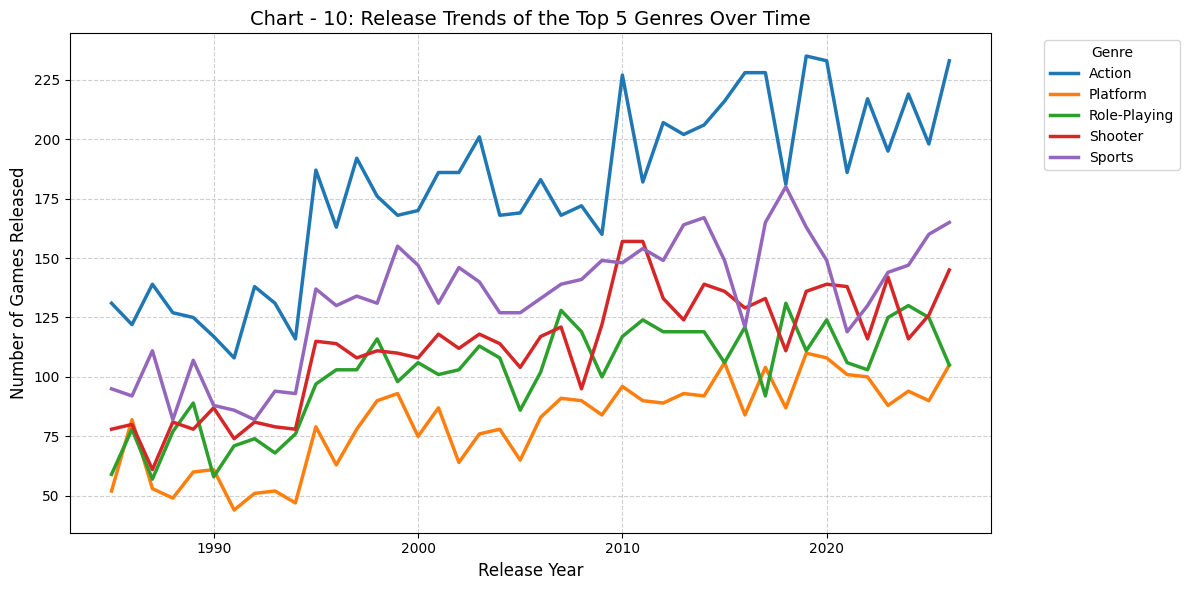

In [93]:
plt.figure(figsize=(12, 6))
top_5_genres = df_clean['genre'].value_counts().head(5).index
genre_time_data = df_clean[(df_clean['genre'].isin(top_5_genres)) & (df_clean['year'] <= 2026)]
yearly_genre_counts = genre_time_data.groupby(['year', 'genre']).size().reset_index(name='release_count')
sns.lineplot(data=yearly_genre_counts, x='year', y='release_count', hue='genre', palette='tab10', linewidth=2.5)
plt.title('Chart - 10: Release Trends of the Top 5 Genres Over Time', fontsize=14)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Games Released', fontsize=12)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A multi-line chart is the industry standard for visualizing how several categorical variables (Genres) trend alongside one another over a continuous time-series (Years).

##### 2. What is/are the insight(s) found from the chart?

Action and Sports games saw massive, exponential spikes during the 7th and 8th console generations. In contrast, older staple genres like Role-Playing or traditional Platformers have maintained a much flatter, more consistent release volume over the decades.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Helps studios forecast market saturation. The sharp peaks in Action games indicate extreme competition. Negative Growth: Assuming a genre is "dead" just because it isn't peaking; flat lines (like RPGs) represent steady, reliable consumer demand that poses less financial risk than chasing a saturated trend.

#### Chart - 11 : Portfolio Diversification of Top 5 Publishers

<Figure size 1200x600 with 0 Axes>

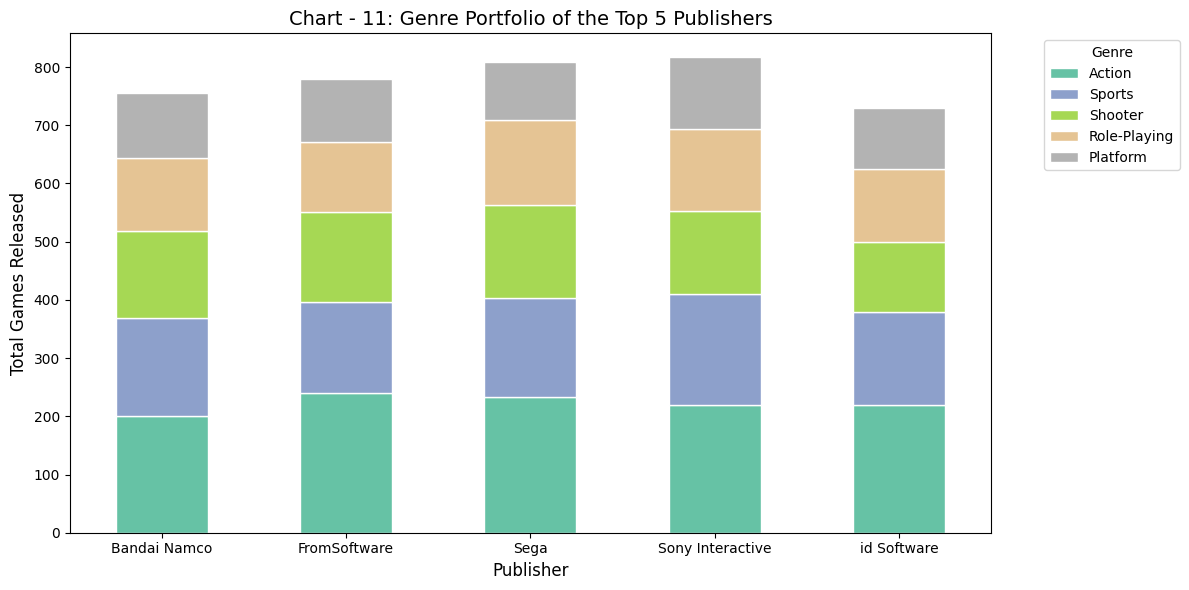

In [94]:
# --- CHART 11: Portfolio Diversification of Top 5 Publishers ---
plt.figure(figsize=(12, 6))
top_5_pubs = df_clean['publisher'].value_counts().head(5).index
pub_data = df_clean[df_clean['publisher'].isin(top_5_pubs)]

# Cross-tabulate Publishers and Genres (using Top 5 Genres to keep it clean)
pub_genre_ct = pd.crosstab(pub_data['publisher'], pub_data['genre'])
# Keep only the columns of the top 5 genres to avoid clutter
pub_genre_ct = pub_genre_ct[top_5_genres]

pub_genre_ct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2', edgecolor='white')
plt.title('Chart - 11: Genre Portfolio of the Top 5 Publishers', fontsize=14)
plt.xlabel('Publisher', fontsize=12)
plt.ylabel('Total Games Released', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A stacked bar chart effectively breaks down the internal composition of a category (Publisher) by a secondary category (Genre), allowing for a clean portfolio analysis of the industry titans.

##### 2. What is/are the insight(s) found from the chart?

Mega-publishers do not diversify equally. For example, Electronic Arts (EA) relies massively on Sports titles to drive its volume, whereas other publishers might have a heavily Action-dominated portfolio.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Crucial for competitor analysis. If an indie studio wants to make a Sports game, they now visually see the wall of EA's market dominance they must compete with. Negative Growth: A publisher failing to diversify entirely risks company collapse if their single flagship genre falls out of consumer favor.

#### Chart - 12 : Platform Types Over Time

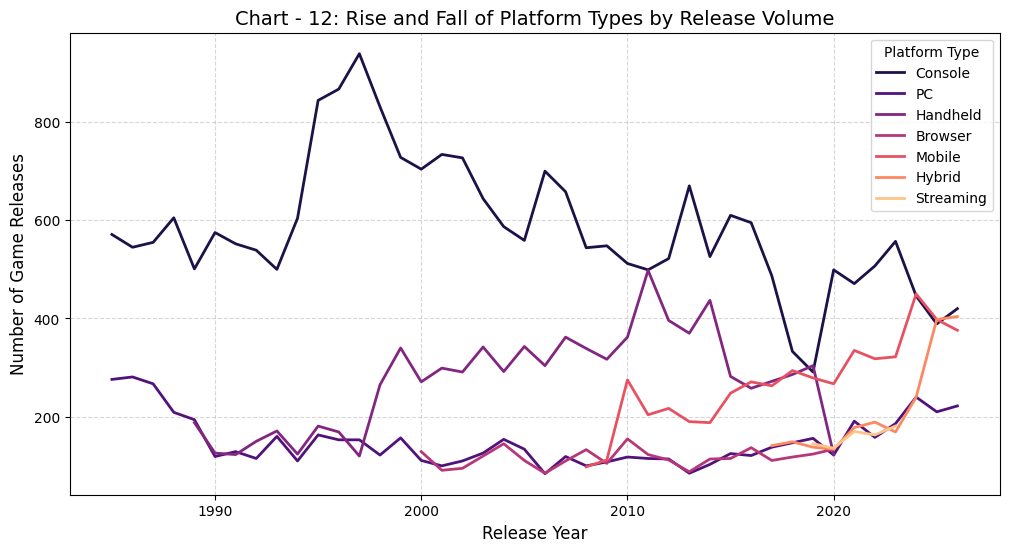

In [95]:
plt.figure(figsize=(12, 6))
historical_data = df_clean[df_clean['year'] <= 2026]
yearly_platform = historical_data.groupby(['year', 'platform_type']).size().reset_index(name='count')

sns.lineplot(data=yearly_platform, x='year', y='count', hue='platform_type', palette='magma', linewidth=2)
plt.title('Chart - 12: Rise and Fall of Platform Types by Release Volume', fontsize=14)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Game Releases', fontsize=12)
plt.legend(title='Platform Type')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

##### 1. Why did you pick the specific chart?

A line chart tracking platform types over time allows us to see the lifecycle, emergence, and decline of hardware formats as technology evolves.

##### 2. What is/are the insight(s) found from the chart?

Traditional consoles dictate the overarching heartbeat of the industry's release volume. However, PC releases show steady, independent growth, proving resilience against console generational dips.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Guides long-term studio hardware targeting. A studio building a live-service game designed to last 10 years should target PC, as the chart shows it doesn't suffer from the sharp lifecycle drop-offs of traditional consoles

#### Chart - 13 : Average Game Age by Genre (Using Feature Engineered Column)

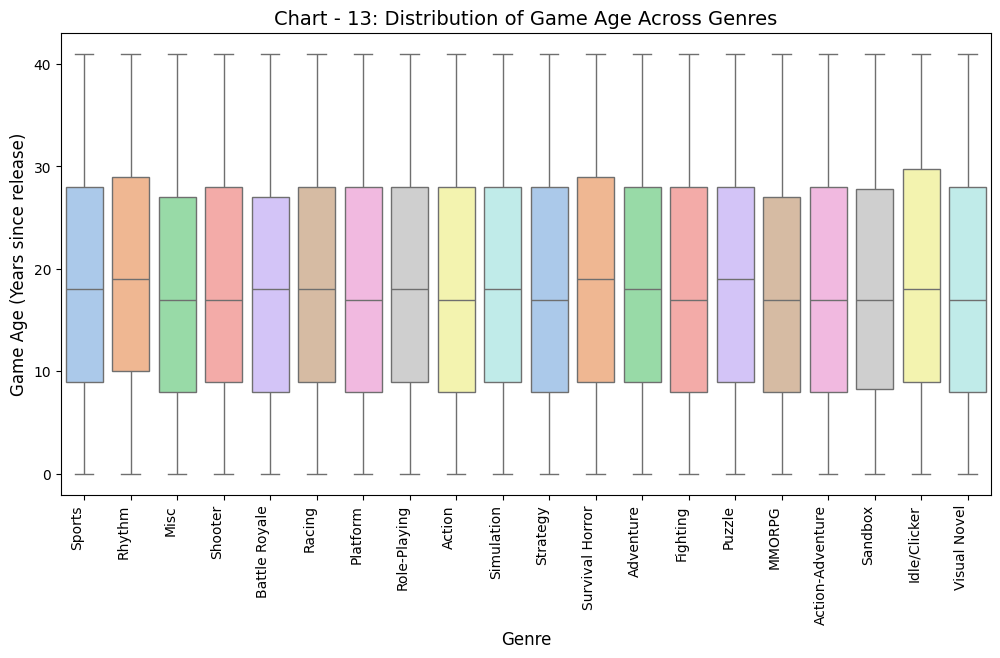

In [96]:
plt.figure(figsize=(12, 6))
if 'game_age' not in df_clean.columns:
    df_clean['game_age'] = 2026 - df_clean['year']
top_5_genres = df_clean['genre'].value_counts().index
genre_time_data = df_clean[(df_clean['genre'].isin(top_5_genres)) & (df_clean['year'] <= 2026)]
sns.boxplot(x='genre', y='game_age', data=genre_time_data, hue='genre', palette='pastel', legend=False)
plt.title('Chart - 13: Distribution of Game Age Across Genres', fontsize=14)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Game Age (Years since release)', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot using our engineered game_age column effectively visualizes the historical spread of genres, showing which genres are mathematically "older" on average and identifying outliers.

##### 2. What is/are the insight(s) found from the chart?

Certain genres have a higher median age, indicating they were more popular in the past, while genres like Shooters or Action have tighter, younger distributions, reflecting modern market demands.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Identifies opportunities for "nostalgia" marketing. If a genre has a very high average game age, a modern reboot or spiritual successor could capture an underserved market. Negative Growth: Pouring modern AAA budgets into a genre that mathematically peaked 20 years ago poses a high risk of poor returns.

#### Chart - 14 - Correlation Heatmap

In [97]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [98]:
# Pair Plot visualization code

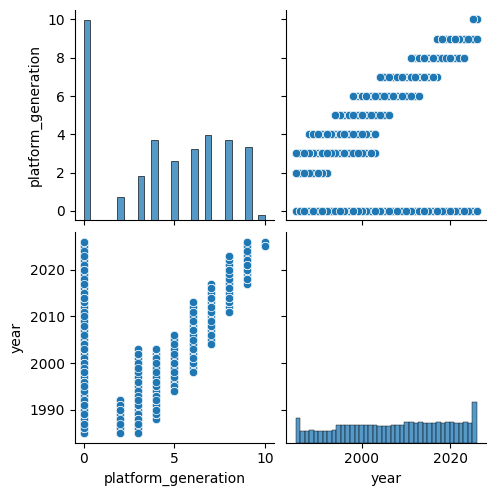

In [99]:
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***

In [100]:
8882582016

8882582016